# NBA Playoff Monte Carlo Simulator
**Method:** Each series is modeled as a sequence of independent Bernoulli trials. The probability that team A beats team B in a single game is derived from their Elo ratings using the standard Elo win-probability formula. We run **10,000 bracket simulations** and record how often each team wins the championship.

**Data:** 2024-25 NBA playoff seedings and estimated Elo ratings based on regular-season performance.

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded.")


Libraries loaded.


## 1. Team data

Elo ratings are estimated from 2024-25 regular season results. Higher = stronger. The exact values matter less than their relative ordering - the simulation is sensitive to the gap between teams, not the absolute numbers.


In [2]:
# 2024-25 NBA Playoff field (corrected — post play-in tournament)
# Seeds 7 and 8 reflect play-in results, not regular-season finish.
#
# East play-in results:
#   7-seed: Orlando Magic (beat Atlanta Hawks in 7v8 game)
#   8-seed: Miami Heat (10-seed; beat Chicago Bulls 9v10, then beat Magic in the second game)
#
# West play-in results:
#   7-seed: Golden State Warriors (beat Memphis Grizzlies in 7v8 game)
#   8-seed: Memphis Grizzlies (beat Dallas Mavericks in 9v10, then beat Warriors in second game)
#
# Elo ratings estimated from 2024-25 regular season W/L and strength of schedule.
# Format: (seed, team, conference, elo)

east_teams = [
    (1, "Cleveland Cavaliers",  "East", 1645),
    (2, "Boston Celtics",       "East", 1615),
    (3, "New York Knicks",      "East", 1565),
    (4, "Indiana Pacers",       "East", 1530),
    (5, "Milwaukee Bucks",      "East", 1520),
    (6, "Detroit Pistons",      "East", 1470),
    (7, "Orlando Magic",        "East", 1475),
    (8, "Miami Heat",           "East", 1445),
]

west_teams = [
    (1, "Oklahoma City Thunder",    "West", 1660),
    (2, "Houston Rockets",          "West", 1590),
    (3, "Los Angeles Lakers",       "West", 1565),
    (4, "Denver Nuggets",           "West", 1555),
    (5, "Los Angeles Clippers",     "West", 1510),
    (6, "Minnesota Timberwolves",   "West", 1515),
    (7, "Golden State Warriors",    "West", 1495),
    (8, "Memphis Grizzlies",        "West", 1465),
]

all_teams = east_teams + west_teams

df_teams = pd.DataFrame(all_teams, columns=["seed", "team", "conference", "elo"])
df_teams = df_teams.sort_values(["conference", "seed"]).reset_index(drop=True)

print(df_teams.to_string(index=False))


 seed                   team conference  elo
    1    Cleveland Cavaliers       East 1645
    2         Boston Celtics       East 1615
    3        New York Knicks       East 1565
    4         Indiana Pacers       East 1530
    5        Milwaukee Bucks       East 1520
    6        Detroit Pistons       East 1470
    7          Orlando Magic       East 1475
    8             Miami Heat       East 1445
    1  Oklahoma City Thunder       West 1660
    2        Houston Rockets       West 1590
    3     Los Angeles Lakers       West 1565
    4         Denver Nuggets       West 1555
    5   Los Angeles Clippers       West 1510
    6 Minnesota Timberwolves       West 1515
    7  Golden State Warriors       West 1495
    8      Memphis Grizzlies       West 1465


## 2. Simulation engine

Two functions do the heavy lifting:

- `win_prob(elo_a, elo_b)` - returns P(team A wins one game) using the Elo formula: `1 / (1 + 10^((elo_b - elo_a) / 400))`
- `simulate_series(team_a, elo_a, team_b, elo_b, best_of)` - simulates a best-of-N series game by game and returns the winner

Home-court advantage adds **+70 Elo points** to the higher seed for games 1, 2, 5, and 7 (standard NBA format).


In [3]:
HOME_COURT_ADVANTAGE = 70  # Elo bump for home team

def win_prob(elo_a: float, elo_b: float) -> float:
    """Probability that team A beats team B in a single game."""
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))


def simulate_series(team_a: str, elo_a: float,
                    team_b: str, elo_b: float,
                    best_of: int = 7) -> tuple[str, int, str]:
    """
    Simulate a playoff series.
    
    Returns (winner_name, games_played, loser_name)
    Higher-seeded team (team_a) has home court.
    Home games for team_a: 1, 2, 5, 7
    Home games for team_b: 3, 4, 6
    """
    wins_needed = (best_of // 2) + 1
    wins_a, wins_b = 0, 0
    game = 0
    home_games_a = {1, 2, 5, 7}  # game numbers where team_a is at home

    while wins_a < wins_needed and wins_b < wins_needed:
        game += 1
        if game in home_games_a:
            p = win_prob(elo_a + HOME_COURT_ADVANTAGE, elo_b)
        else:
            p = win_prob(elo_a, elo_b + HOME_COURT_ADVANTAGE)

        if np.random.random() < p:
            wins_a += 1
        else:
            wins_b += 1

    winner = team_a if wins_a == wins_needed else team_b
    loser  = team_b if wins_a == wins_needed else team_a
    return winner, game, loser


# Quick sanity check
winner, games, loser = simulate_series("OKC Thunder", 1660, "LAL Lakers", 1575)
print(f"Test series: {winner} beat {loser} in {games} games")
p = win_prob(1660, 1575)
print(f"OKC single-game win prob vs LAL: {p:.3f}")


Test series: OKC Thunder beat LAL Lakers in 7 games
OKC single-game win prob vs LAL: 0.620


## 3. Full bracket simulation

`simulate_bracket()` runs one complete playoff from first round to Finals. The bracket reseeds after each round (NBA format): the lowest remaining seed always plays the highest remaining seed within the conference.


In [4]:
def get_elo(team_name: str, elo_map: dict) -> float:
    return elo_map[team_name]


def simulate_conference(seeds_and_teams: list, elo_map: dict) -> str:
    """
    Simulate one conference bracket through three rounds.
    seeds_and_teams: list of (seed, team_name) sorted by seed ascending
    Returns conference champion name.
    """
    remaining = seeds_and_teams[:]  # (seed, team)

    for _round in range(3):  # R1, Semis, Finals
        # Re-seed: lowest seed vs highest seed
        remaining.sort(key=lambda x: x[0])
        next_round = []
        while len(remaining) >= 2:
            top    = remaining.pop(0)   # best remaining seed
            bottom = remaining.pop(-1)  # worst remaining seed
            winner_name, _, _ = simulate_series(
                top[1],    get_elo(top[1], elo_map),
                bottom[1], get_elo(bottom[1], elo_map)
            )
            winner_seed = top[0] if winner_name == top[1] else bottom[0]
            next_round.append((winner_seed, winner_name))
        remaining = next_round

    return remaining[0][1]  # conference champion


def simulate_bracket(df: pd.DataFrame) -> str:
    """Run one full playoff bracket, return champion name."""
    elo_map = dict(zip(df["team"], df["elo"]))

    east = [(row.seed, row.team) for row in df[df.conference == "East"].itertuples()]
    west = [(row.seed, row.team) for row in df[df.conference == "West"].itertuples()]

    east_champ = simulate_conference(east, elo_map)
    west_champ = simulate_conference(west, elo_map)

    # NBA Finals - no home-court advantage based on conference, use Elo
    east_elo = elo_map[east_champ]
    west_elo = elo_map[west_champ]
    # Higher Elo gets home court in Finals
    if east_elo >= west_elo:
        champ, _, _ = simulate_series(east_champ, east_elo, west_champ, west_elo)
    else:
        champ, _, _ = simulate_series(west_champ, west_elo, east_champ, east_elo)

    return champ


# Test one run
champ = simulate_bracket(df_teams)
print(f"Test run champion: {champ}")


Test run champion: Oklahoma City Thunder


## 4. Run 10,000 simulations


In [5]:
N_SIMS = 10_000

results = [simulate_bracket(df_teams) for _ in range(N_SIMS)]

# Tally
from collections import Counter
counts = Counter(results)

df_results = pd.DataFrame([
    {"team": team, "titles": count, "probability": count / N_SIMS}
    for team, count in counts.items()
])

# Merge with team metadata
df_results = df_results.merge(df_teams[["team", "conference", "seed", "elo"]], on="team")
df_results = df_results.sort_values("probability", ascending=False).reset_index(drop=True)
df_results["rank"] = df_results.index + 1

print(f"Simulations run: {N_SIMS:,}")
print()
print(df_results[["rank", "team", "conference", "seed", "elo", "titles", "probability"]]
      .to_string(index=False))


Simulations run: 10,000

 rank                   team conference  seed  elo  titles  probability
    1  Oklahoma City Thunder       West     1 1660    3970       0.3970
    2    Cleveland Cavaliers       East     1 1645    3074       0.3074
    3         Boston Celtics       East     2 1615    1293       0.1293
    4        Houston Rockets       West     2 1590     698       0.0698
    5     Los Angeles Lakers       West     3 1565     288       0.0288
    6        New York Knicks       East     3 1565     287       0.0287
    7         Denver Nuggets       West     4 1555     174       0.0174
    8         Indiana Pacers       East     4 1530      80       0.0080
    9        Milwaukee Bucks       East     5 1520      37       0.0037
   10 Minnesota Timberwolves       West     6 1515      35       0.0035
   11   Los Angeles Clippers       West     5 1510      30       0.0030
   12  Golden State Warriors       West     7 1495      16       0.0016
   13        Detroit Pistons       East

## 5. Championship probability by team


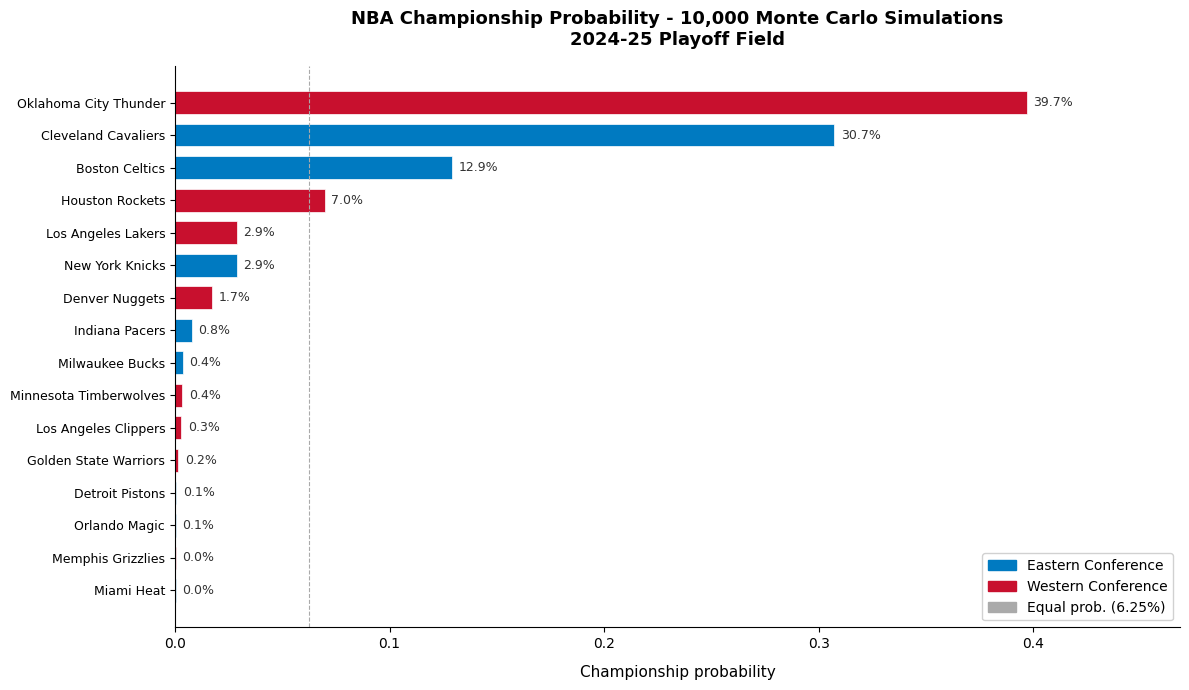

Saved: championship_probability.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ["#007AC1" if c == "East" else "#C8102E"
          for c in df_results["conference"]]

bars = ax.barh(
    df_results["team"][::-1],
    df_results["probability"][::-1],
    color=colors[::-1],
    edgecolor="white",
    linewidth=0.5,
    height=0.7
)

# Probability labels
for bar, prob in zip(bars, df_results["probability"][::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{prob:.1%}", va="center", ha="left", fontsize=9, color="#333333")

ax.set_xlabel("Championship probability", fontsize=11, labelpad=10)
ax.set_title(f"NBA Championship Probability - {N_SIMS:,} Monte Carlo Simulations\n2024-25 Playoff Field", fontsize=13, pad=15, fontweight="bold")
ax.set_xlim(0, df_results["probability"].max() * 1.18)
ax.axvline(1 / 16, color="#aaaaaa", linestyle="--", linewidth=0.8, label="Equal probability (6.25%)")

east_patch = mpatches.Patch(color="#007AC1", label="Eastern Conference")
west_patch = mpatches.Patch(color="#C8102E", label="Western Conference")
ax.legend(handles=[east_patch, west_patch, 
                   mpatches.Patch(color="#aaaaaa", label="Equal prob. (6.25%)")],
          loc="lower right", framealpha=0.9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig("championship_probability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: championship_probability.png")


## 6. Series length distribution

How often do series go to 4, 5, 6, or 7 games? We re-run a targeted simulation between the two top seeds to get the distribution.


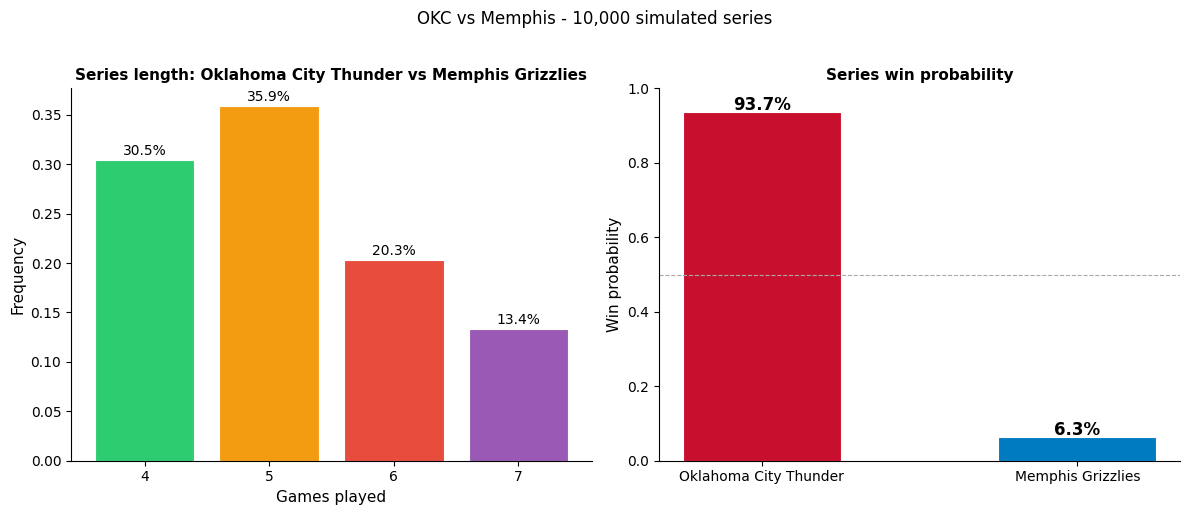

Saved: series_analysis.png


In [7]:
# Simulate 10k series between #1 East (Cavs) and #1 West (OKC)
team_a, elo_a = "Oklahoma City Thunder", 1660
team_b, elo_b = "Memphis Grizzlies",     1465

series_lengths = []
series_winners = []

for _ in range(N_SIMS):
    w, g, _ = simulate_series(team_a, elo_a, team_b, elo_b)
    series_lengths.append(g)
    series_winners.append(w)

length_counts = Counter(series_lengths)
winner_counts = Counter(series_winners)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Series length
ax = axes[0]
lengths = [4, 5, 6, 7]
freqs   = [length_counts.get(l, 0) / N_SIMS for l in lengths]
ax.bar(lengths, freqs, color=["#2ecc71", "#f39c12", "#e74c3c", "#9b59b6"],
       edgecolor="white", linewidth=0.8)
for l, f in zip(lengths, freqs):
    ax.text(l, f + 0.005, f"{f:.1%}", ha="center", fontsize=10)
ax.set_xlabel("Games played", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.set_title(f"Series length: {team_a} vs {team_b}", fontsize=11, fontweight="bold")
ax.set_xticks(lengths)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Win probability
ax = axes[1]
teams  = [team_a, team_b]
probs  = [winner_counts[t] / N_SIMS for t in teams]
colors2 = ["#C8102E", "#007AC1"]
bars = ax.bar(teams, probs, color=colors2, edgecolor="white", linewidth=0.8, width=0.5)
for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width() / 2, p + 0.005, f"{p:.1%}",
            ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Win probability", fontsize=11)
ax.set_title("Series win probability", fontsize=11, fontweight="bold")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="#aaaaaa", linestyle="--", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.suptitle(f"OKC vs Memphis - {N_SIMS:,} simulated series", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("series_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: series_analysis.png")


## 7. Sensitivity analysis

How sensitive is OKC's championship probability to their Elo rating? We sweep OKC's Elo from ±150 and re-run 5,000 simulations at each value.


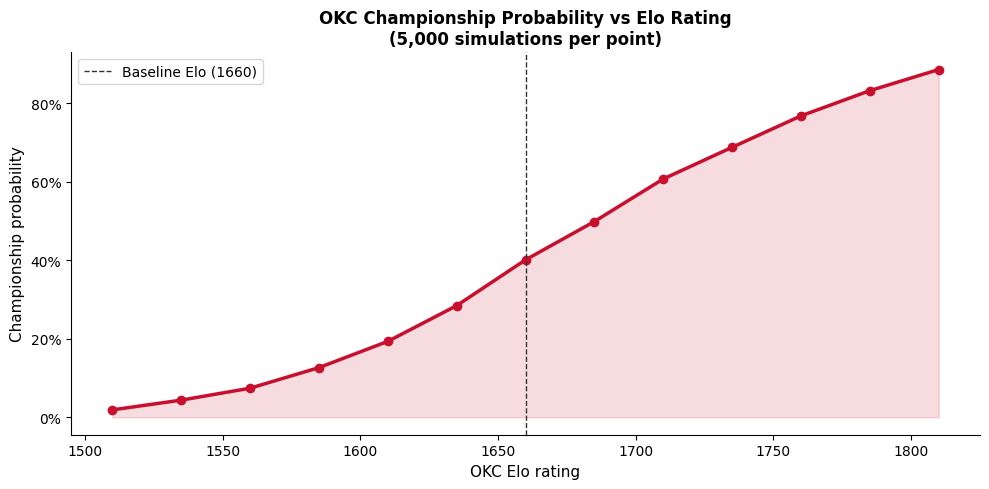

Saved: sensitivity_analysis.png


In [8]:
base_elo = 1660
elo_offsets = range(-150, 175, 25)
okc_probs = []

for offset in elo_offsets:
    df_mod = df_teams.copy()
    df_mod.loc[df_mod["team"] == "Oklahoma City Thunder", "elo"] = base_elo + offset
    wins = sum(1 for _ in range(5_000) if simulate_bracket(df_mod) == "Oklahoma City Thunder")
    okc_probs.append(wins / 5_000)

fig, ax = plt.subplots(figsize=(10, 5))
elo_values = [base_elo + o for o in elo_offsets]
ax.plot(elo_values, okc_probs, color="#C8102E", linewidth=2.5, marker="o", markersize=6)
ax.axvline(base_elo, color="#333333", linestyle="--", linewidth=1, label=f"Baseline Elo ({base_elo})")
ax.fill_between(elo_values, okc_probs, alpha=0.15, color="#C8102E")
ax.set_xlabel("OKC Elo rating", fontsize=11)
ax.set_ylabel("Championship probability", fontsize=11)
ax.set_title("OKC Championship Probability vs Elo Rating\n(5,000 simulations per point)", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("sensitivity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sensitivity_analysis.png")


## 8. Summary statistics


In [9]:
print("=" * 55)
print(f"  NBA Championship Probabilities - {N_SIMS:,} simulations")
print("=" * 55)

for _, row in df_results.iterrows():
    bar = "X" * int(row.probability * 200)
    pct = f"{row.probability:.1%}"
    print(f"  {int(row['rank']):>2}. {row.team:<28} {pct:>6}  {bar}")

print()
okc_prob = df_results[df_results.team == "Oklahoma City Thunder"]["probability"].values[0]
print(f"  Top seed advantage (OKC vs equal field): {okc_prob:.1%} vs 6.25% baseline")
print()

east_prob = df_results[df_results.conference == "East"]["probability"].sum()
west_prob = df_results[df_results.conference == "West"]["probability"].sum()
print(f"  East teams win combined: {east_prob:.1%}")
print(f"  West teams win combined: {west_prob:.1%}")


  NBA Championship Probabilities - 10,000 simulations
   1. Oklahoma City Thunder         39.7%  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
   2. Cleveland Cavaliers           30.7%  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
   3. Boston Celtics                12.9%  XXXXXXXXXXXXXXXXXXXXXXXXX
   4. Houston Rockets                7.0%  XXXXXXXXXXXXX
   5. Los Angeles Lakers             2.9%  XXXXX
   6. New York Knicks                2.9%  XXXXX
   7. Denver Nuggets                 1.7%  XXX
   8. Indiana Pacers                 0.8%  X
   9. Milwaukee Bucks                0.4%  
  10. Minnesota Timberwolves         0.4%  
  11. Los Angeles Clippers           0.3%  
  12. Golden State Warriors          0.2%  
  13. Detroit Pistons                0.1%  
  14. Orlando Magic                  0.1%  
  15. Memphis Grizzlies              0.0%  
  16. Miami Heat                     0.0%  

  Top seed advantage (OKC vs equal field): 39.7% 


---
*Simulation built with NumPy. Elo ratings estimated from 2024-25 regular season results.*
